# Thesis Implementation Notebook

This notebook contains the computational workflow used for the master's thesis **Comparative Classification of Short Mental-Health-Related Texts Using Lexical and Semantic Representations**.

The workflow covers dataset loading, empty-statement inspection, text preprocessing, lexical and semantic representation, supervised model comparison, final hold-out evaluation, class-level analysis, and export of reproducibility outputs. The task is treated as a non-clinical text classification experiment.


## 1. Environment setup

This section defines the working paths and main experimental constants used throughout the notebook.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DATA_PATH = '/content/drive/MyDrive/MentalHealthData.csv'
OUTPUT_DIR = Path('/content/drive/MyDrive/mental_health_thesis_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

print('Dataset path:', DATA_PATH)
print('Output folder:', OUTPUT_DIR)


Mounted at /content/drive
Dataset path: /content/drive/MyDrive/MentalHealthData.csv
Output folder: /content/drive/MyDrive/mental_health_thesis_outputs


## 2. Library installation and imports

The required libraries support data handling, NLP preprocessing, model training, evaluation, visualisation, and sentence embedding generation.


In [2]:
!pip -q install sentence-transformers


In [3]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

nltk.download('stopwords')
nltk.download('wordnet')

print('GPU available:', torch.cuda.is_available())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


GPU available: True


### 2.1 Package versions

The main package versions are recorded to support reproducibility.


In [4]:
import sklearn
import matplotlib
import sentence_transformers

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('nltk:', nltk.__version__)
print('sentence-transformers:', sentence_transformers.__version__)
print('matplotlib:', matplotlib.__version__)
print('torch:', torch.__version__)


pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
nltk: 3.9.1
sentence-transformers: 5.5.1
matplotlib: 3.10.0
torch: 2.11.0+cu128


## 3. Dataset loading

The dataset is loaded, the index column is removed when present, and the required text and label columns are validated.


In [5]:
df = pd.read_csv(DATA_PATH)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

required_cols = {'statement', 'status'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}. Found columns: {list(df.columns)}')

df['statement'] = df['statement'].fillna('').astype(str)
df['status'] = df['status'].astype(str)

print('Dataset shape after dropping index column if present:', df.shape)
print('Columns:', df.columns.tolist())
print('Number of target classes:', df['status'].nunique())


Dataset shape after dropping index column if present: (53043, 2)
Columns: ['statement', 'status']
Number of target classes: 7


## 4. Initial dataset inspection

Before modelling, the dataset is inspected for class distribution, empty statements, and very short statements.


In [6]:
print('Original class distribution:')
class_counts_original = df['status'].value_counts()
display(class_counts_original)

print('\nOriginal class distribution (%):')
class_percent_original = (df['status'].value_counts(normalize=True) * 100).round(2)
display(class_percent_original)

Original class distribution:


,count
status,
Normal,16351
Depression,15404
Suicidal,10653
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201



Original class distribution (%):


,proportion
status,
Normal,30.83
Depression,29.04
Suicidal,20.08
Anxiety,7.33
Bipolar,5.42
Stress,5.03
Personality disorder,2.26


In [7]:
empty_rows = df[df['statement'].fillna('').str.strip() == ''].copy()
short_texts = df[df['statement'].fillna('').str.len() < 15].copy()

print('Number of empty statements:', len(empty_rows))
print('Percentage of empty statements:', round(len(empty_rows) / len(df) * 100, 4), '%')
print('Number of statements with < 15 characters:', len(short_texts))
print('Percentage of statements with < 15 characters:', round(len(short_texts) / len(df) * 100, 4), '%')


Number of empty statements: 362
Percentage of empty statements: 0.6825 %
Number of statements with < 15 characters: 1497
Percentage of statements with < 15 characters: 2.8222 %


In [8]:
empty_by_class = (
    empty_rows['status']
    .value_counts()
    .rename_axis('status')
    .reset_index(name='empty_count')
)

class_counts_df = (
    df['status']
    .value_counts()
    .rename_axis('status')
    .reset_index(name='total_class_count')
)

empty_impact = class_counts_df.merge(empty_by_class, on='status', how='left')
empty_impact['empty_count'] = empty_impact['empty_count'].fillna(0).astype(int)

empty_impact['empty_percentage_within_class'] = (
    empty_impact['empty_count'] / empty_impact['total_class_count'] * 100
).round(2)

empty_impact = empty_impact.sort_values(
    'empty_percentage_within_class',
    ascending=False
)

print('Empty statements by class:')
display(empty_impact)

empty_impact.to_csv(OUTPUT_DIR / 'empty_statement_impact_by_class.csv', index=False)

Empty statements by class:


,status,total_class_count,empty_count,empty_percentage_within_class
6,Personality disorder,1201,124,10.32
4,Bipolar,2877,100,3.48
5,Stress,2669,82,3.07
3,Anxiety,3888,47,1.21
0,Normal,16351,8,0.05
2,Suicidal,10653,1,0.01
1,Depression,15404,0,0.00


## 5. Empty-statement removal

Empty statements are removed because they do not contain usable linguistic information. Very short non-empty statements are retained because they may still contain relevant short-text cues.


In [9]:
rows_before = len(df)

df = df[df['statement'].fillna('').str.strip() != ''].copy()
df = df.reset_index(drop=True)

rows_after = len(df)
rows_removed = rows_before - rows_after

print('Rows before removing empty statements:', rows_before)
print('Rows removed:', rows_removed)
print('Rows after removing empty statements:', rows_after)
print('Percentage removed:', round(rows_removed / rows_before * 100, 4), '%')

assert df['statement'].str.strip().eq('').sum() == 0, 'Empty statements still remain after filtering.'


Rows before removing empty statements: 53043
Rows removed: 362
Rows after removing empty statements: 52681
Percentage removed: 0.6825 %


### 5.1 Class distribution after empty-statement removal

The following table and figure describe the final class distribution used for modelling.


Cleaned dataset class distribution:


,category,number_of_statements,percentage
0,Normal,16343,31.02
1,Depression,15404,29.24
2,Suicidal,10652,20.22
3,Anxiety,3841,7.29
4,Bipolar,2777,5.27
5,Stress,2587,4.91
6,Personality disorder,1077,2.04


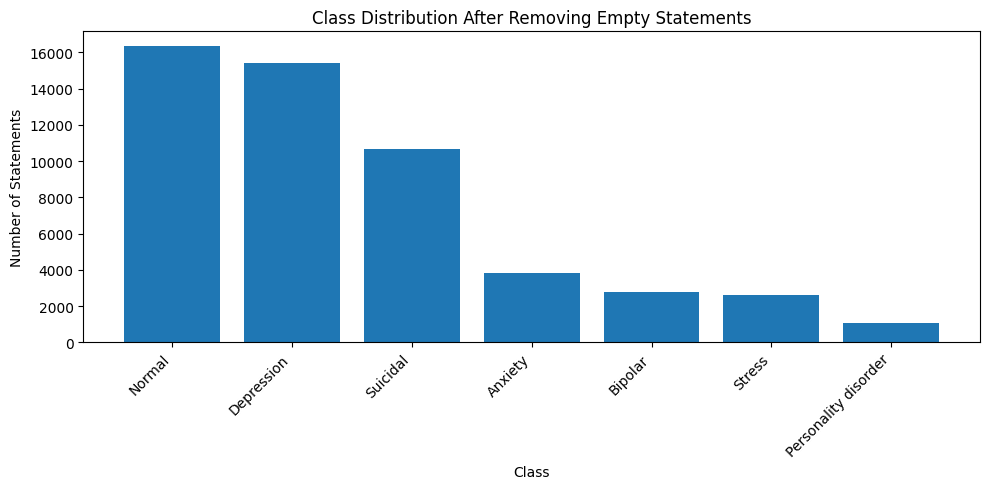

In [10]:
class_counts = df['status'].value_counts().sort_values(ascending=False)
class_distribution_df = class_counts.rename_axis('category').reset_index(name='number_of_statements')
class_distribution_df['percentage'] = (class_distribution_df['number_of_statements'] / len(df) * 100).round(2)

print('Cleaned dataset class distribution:')
display(class_distribution_df)

class_distribution_df.to_csv(OUTPUT_DIR / 'class_distribution_after_empty_removal.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(class_distribution_df['category'], class_distribution_df['number_of_statements'])
ax.set_title('Class Distribution After Removing Empty Statements')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Statements')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_class_distribution_after_empty_removal.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Text preprocessing

A cleaned text column is created for all model configurations. The preprocessing keeps negation and self-reference terms because these expressions may carry relevant meaning in mental-health-related language.


In [11]:
lemmatizer = WordNetLemmatizer()
base_stop_words = set(stopwords.words('english'))

protected_words = {
    'i', "i'm", "i'll", "i've", "i'd", 'me', 'my', 'myself',
    'no', 'nor', 'not',
    "aren't", "couldn't", "didn't", "doesn't", "don't",
    "hadn't", "hasn't", "haven't", "isn't", "mightn't",
    "mustn't", "needn't", "shan't", "shouldn't",
    "wasn't", "weren't", "won't", "wouldn't", "can't"
}

custom_stop_words = base_stop_words - protected_words

def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s!?'.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [token for token in tokens if token not in custom_stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

df['statement_clean'] = df['statement'].apply(preprocess_text)

print('Cleaned text column created:', 'statement_clean')
print('Rows with empty cleaned text:', int((df['statement_clean'].str.strip() == '').sum()))


Cleaned text column created: statement_clean
Rows with empty cleaned text: 10


## 7. Input and target variables

The cleaned statement column is used as model input, while the status column is used as the target label.


In [12]:
X_df = df[['statement_clean']].copy()
y = df['status'].copy()

print('Input shape:', X_df.shape)
print('Target shape:', y.shape)
print('Number of classes:', y.nunique())
print('Classes:', sorted(y.unique()))


Input shape: (52681, 1)
Target shape: (52681,)
Number of classes: 7
Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## 8. Text-column selector

The selector allows scikit-learn pipelines to receive a DataFrame while using only the cleaned text column.


In [13]:
def select_text_column(X):
    if isinstance(X, pd.DataFrame):
        return X['statement_clean']
    return X

text_selector = FunctionTransformer(select_text_column, validate=False)

## 9. Candidate model configurations

Seven supervised learning configurations are defined to compare lexical TF-IDF representations and semantic sentence embeddings under the same evaluation framework.


In [14]:
tfidf_models = {
    'TF-IDF + Logistic Regression': Pipeline([
        ('selector', text_selector),
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf', LogisticRegression(max_iter=2000, n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    'TF-IDF + Naive Bayes': Pipeline([
        ('selector', text_selector),
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf', MultinomialNB())
    ]),
    'TF-IDF + Random Forest': Pipeline([
        ('selector', text_selector),
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    'TF-IDF (word + char) + Linear SVM': Pipeline([
        ('selector', text_selector),
        ('features', FeatureUnion([
            ('word_tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), analyzer='word')),
            ('char_tfidf', TfidfVectorizer(max_features=5000, ngram_range=(3, 5), analyzer='char_wb'))
        ])),
        ('clf', LinearSVC(random_state=RANDOM_STATE))
    ]),
}

embedding_model_name = 'all-MiniLM-L6-v2'

embedding_models = {
    'Embeddings + Logistic Regression': LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'Embeddings + Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Embeddings + Linear SVM': LinearSVC(
        random_state=RANDOM_STATE
    )
}

candidate_configurations_df = pd.DataFrame([
    {'branch': 'Lexical', 'representation': 'TF-IDF', 'classifier': 'Logistic Regression'},
    {'branch': 'Lexical', 'representation': 'TF-IDF', 'classifier': 'Multinomial Naive Bayes'},
    {'branch': 'Lexical', 'representation': 'TF-IDF', 'classifier': 'Random Forest'},
    {'branch': 'Lexical', 'representation': 'TF-IDF word + character', 'classifier': 'Linear SVM'},
    {'branch': 'Semantic', 'representation': 'Sentence embeddings', 'classifier': 'Logistic Regression'},
    {'branch': 'Semantic', 'representation': 'Sentence embeddings', 'classifier': 'Random Forest'},
    {'branch': 'Semantic', 'representation': 'Sentence embeddings', 'classifier': 'Linear SVM'},
])

candidate_configurations_df.to_csv(OUTPUT_DIR / 'candidate_model_configurations.csv', index=False)
display(candidate_configurations_df)

print('Number of candidate models:', len(tfidf_models) + len(embedding_models))


,branch,representation,classifier
0,Lexical,TF-IDF,Logistic Regression
1,Lexical,TF-IDF,Multinomial Naive Bayes
2,Lexical,TF-IDF,Random Forest
3,Lexical,TF-IDF word + character,Linear SVM
4,Semantic,Sentence embeddings,Logistic Regression
5,Semantic,Sentence embeddings,Random Forest
6,Semantic,Sentence embeddings,Linear SVM


Number of candidate models: 7


## 10. Stratified five-fold cross-validation

Candidate configurations are compared using stratified five-fold cross-validation. Macro F1 is used as the main model-selection metric, with Accuracy and Weighted F1 reported as supporting metrics.


In [15]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'macro_f1': 'f1_macro',
    'weighted_f1': 'f1_weighted'
}

cv_results = []

for model_name, pipeline in tfidf_models.items():
    print(f'Running 5-fold CV for: {model_name}')

    scores = cross_validate(
        pipeline,
        X_df,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        'model': model_name,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'macro_f1_mean': scores['test_macro_f1'].mean(),
        'macro_f1_std': scores['test_macro_f1'].std(),
        'weighted_f1_mean': scores['test_weighted_f1'].mean(),
        'weighted_f1_std': scores['test_weighted_f1'].std()
    })

embedding_device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Precomputing sentence embeddings once for all texts.')
print('Embedding device:', embedding_device)

embedding_model = SentenceTransformer(embedding_model_name, device=embedding_device)

X_emb = embedding_model.encode(
    X_df['statement_clean'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

for model_name, model in embedding_models.items():
    print(f'Running 5-fold CV for: {model_name}')

    scores = cross_validate(
        model,
        X_emb,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        'model': model_name,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'macro_f1_mean': scores['test_macro_f1'].mean(),
        'macro_f1_std': scores['test_macro_f1'].std(),
        'weighted_f1_mean': scores['test_weighted_f1'].mean(),
        'weighted_f1_std': scores['test_weighted_f1'].std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(by='macro_f1_mean', ascending=False)
    .reset_index(drop=True)
)

cv_results_df.to_csv(
    OUTPUT_DIR / 'cross_validation_results.csv',
    index=False
)

print('Cross-validation results ranked by mean Macro F1:')
display(cv_results_df.round(4))

Running 5-fold CV for: TF-IDF + Logistic Regression
Running 5-fold CV for: TF-IDF + Naive Bayes
Running 5-fold CV for: TF-IDF + Random Forest


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Running 5-fold CV for: TF-IDF (word + char) + Linear SVM
Precomputing sentence embeddings once for all texts.
Embedding device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1647 [00:00<?, ?it/s]

Running 5-fold CV for: Embeddings + Logistic Regression
Running 5-fold CV for: Embeddings + Random Forest
Running 5-fold CV for: Embeddings + Linear SVM
Cross-validation results ranked by mean Macro F1:


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,TF-IDF (word + char) + Linear SVM,0.7699,0.0040,0.7312,0.0088,0.7669,0.0039
1,TF-IDF + Logistic Regression,0.7616,0.0045,0.7083,0.0081,0.7561,0.0045
2,Embeddings + Linear SVM,0.7485,0.0021,0.6782,0.0058,0.7424,0.0021
3,Embeddings + Logistic Regression,0.7469,0.0031,0.6779,0.0074,0.7420,0.0031
4,TF-IDF + Random Forest,0.7236,0.0035,0.6409,0.0059,0.7119,0.0034
5,Embeddings + Random Forest,0.7100,0.0017,0.6101,0.0061,0.6925,0.0013
6,TF-IDF + Naive Bayes,0.6831,0.0024,0.5517,0.0070,0.6691,0.0025


## 11. Cross-validation figures

The cross-validation results are exported as figures for the thesis document.


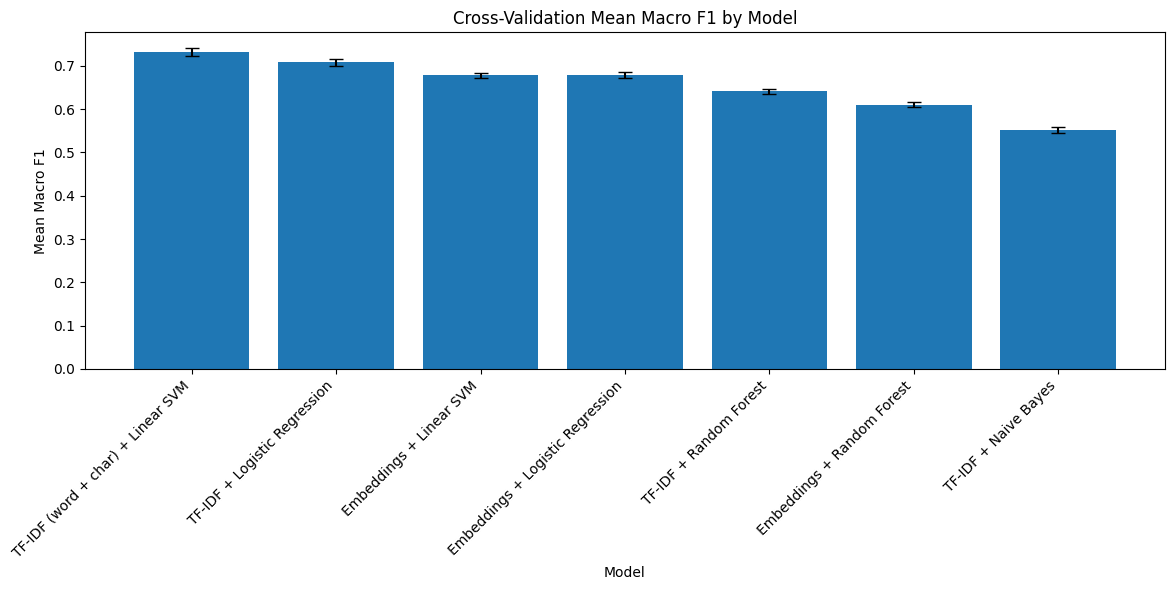

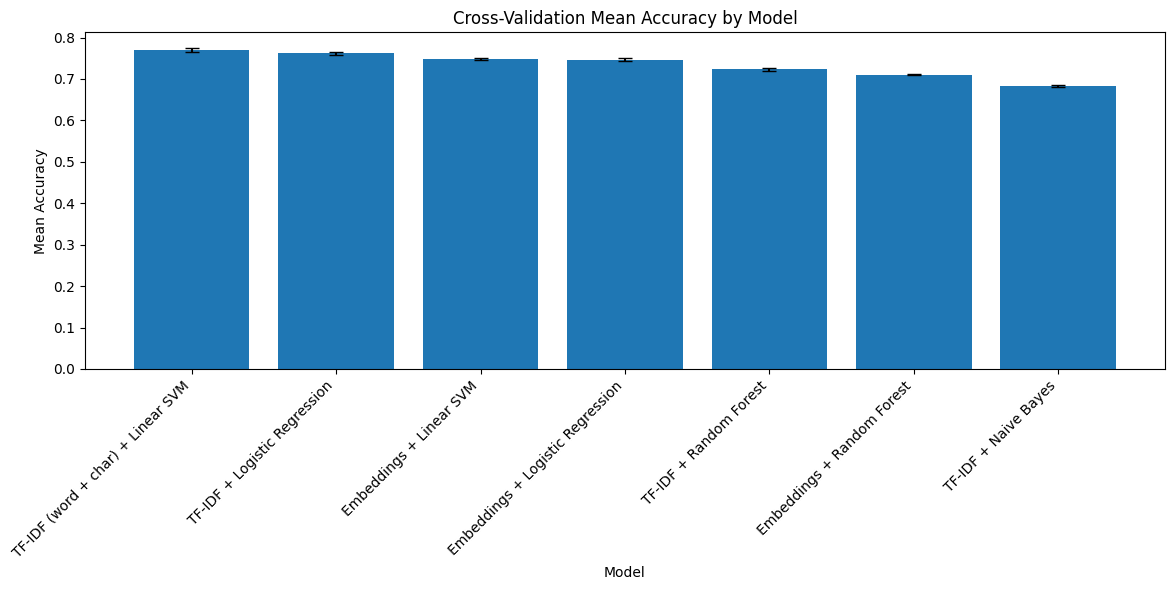

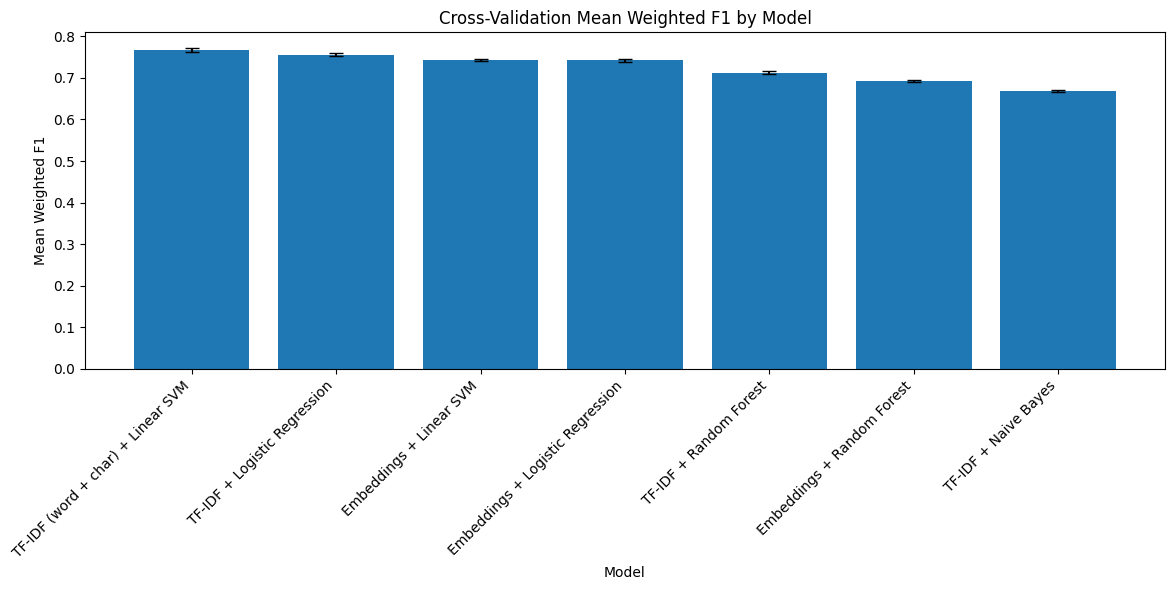

In [16]:
def save_cv_bar(metric_mean, metric_std, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(
        cv_results_df['model'],
        cv_results_df[metric_mean],
        yerr=cv_results_df[metric_std],
        capsize=5
    )
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

save_cv_bar(
    'macro_f1_mean',
    'macro_f1_std',
    'Cross-Validation Mean Macro F1 by Model',
    'Mean Macro F1',
    'figure_cv_macro_f1_by_model.png'
)

save_cv_bar(
    'accuracy_mean',
    'accuracy_std',
    'Cross-Validation Mean Accuracy by Model',
    'Mean Accuracy',
    'figure_cv_accuracy_by_model.png'
)

save_cv_bar(
    'weighted_f1_mean',
    'weighted_f1_std',
    'Cross-Validation Mean Weighted F1 by Model',
    'Mean Weighted F1',
    'figure_cv_weighted_f1_by_model.png'
)


## 12. Model selection

The selected configuration is the model with the highest mean Macro F1 across the five validation folds.


In [17]:
best_model_name = cv_results_df.iloc[0]['model']
print(f'Best model from CV: {best_model_name}')


Best model from CV: TF-IDF (word + char) + Linear SVM


## 13. Final hold-out evaluation

The selected model is evaluated on a final stratified 80/20 hold-out test set.


In [18]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train size:', len(X_train_df))
print('Test size:', len(X_test_df))

if best_model_name in tfidf_models:
    best_model = tfidf_models[best_model_name]
    best_model.fit(X_train_df, y_train)
    y_pred = best_model.predict(X_test_df)

else:
    embedding_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    embedding_model = SentenceTransformer(embedding_model_name, device=embedding_device)

    X_train_emb = embedding_model.encode(
        X_train_df['statement_clean'].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True
    )

    X_test_emb = embedding_model.encode(
        X_test_df['statement_clean'].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True
    )

    if best_model_name == 'Embeddings + Logistic Regression':
        best_model = LogisticRegression(max_iter=2000, n_jobs=-1, random_state=RANDOM_STATE)
    elif best_model_name == 'Embeddings + Random Forest':
        best_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    elif best_model_name == 'Embeddings + Linear SVM':
        best_model = LinearSVC(random_state=RANDOM_STATE)
    else:
        raise ValueError(f'Unexpected best model: {best_model_name}')

    best_model.fit(X_train_emb, y_train)
    y_pred = best_model.predict(X_test_emb)

final_accuracy = accuracy_score(y_test, y_pred)
final_macro_f1 = f1_score(y_test, y_pred, average='macro')
final_weighted_f1 = f1_score(y_test, y_pred, average='weighted')

final_results_df = pd.DataFrame([
    {
        'best_model': best_model_name,
        'accuracy': final_accuracy,
        'macro_f1': final_macro_f1,
        'weighted_f1': final_weighted_f1
    }
])

final_results_df.to_csv(
    OUTPUT_DIR / 'final_holdout_results.csv',
    index=False
)

print('Final hold-out results for the winning model:')
display(final_results_df.round(4))

print('Classification report:')
print(classification_report(y_test, y_pred))

Train size: 42144
Test size: 10537
Final hold-out results for the winning model:


,best_model,accuracy,macro_f1,weighted_f1
0,TF-IDF (word + char) + Linear SVM,0.7665,0.7269,0.7638


Classification report:
                      precision    recall  f1-score   support

             Anxiety       0.80      0.75      0.77       768
             Bipolar       0.82      0.75      0.79       556
          Depression       0.71      0.72      0.71      3081
              Normal       0.88      0.94      0.91      3269
Personality disorder       0.75      0.60      0.67       215
              Stress       0.65      0.52      0.58       517
            Suicidal       0.67      0.65      0.66      2131

            accuracy                           0.77     10537
           macro avg       0.75      0.71      0.73     10537
        weighted avg       0.76      0.77      0.76     10537



### 13.1 Classification report export

The final classification report is converted into a table and exported for thesis reporting.


In [19]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
classification_report_df = pd.DataFrame(report_dict).transpose()
classification_report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')
display(classification_report_df.round(4))


,precision,recall,f1-score,support
Anxiety,0.8025,0.7461,0.7733,768.0000
Bipolar,0.8200,0.7536,0.7854,556.0000
Depression,0.7054,0.7167,0.7110,3081.0000
Normal,0.8815,0.9440,0.9117,3269.0000
Personality disorder,0.7471,0.6047,0.6684,215.0000
Stress,0.6483,0.5242,0.5797,517.0000
Suicidal,0.6654,0.6523,0.6588,2131.0000
accuracy,0.7665,0.7665,0.7665,0.7665
macro avg,0.7529,0.7059,0.7269,10537.0000
weighted avg,0.7631,0.7665,0.7638,10537.0000


## 14. Final evaluation figures

This section exports the final metric chart, class-level F1 chart, and confusion matrix.


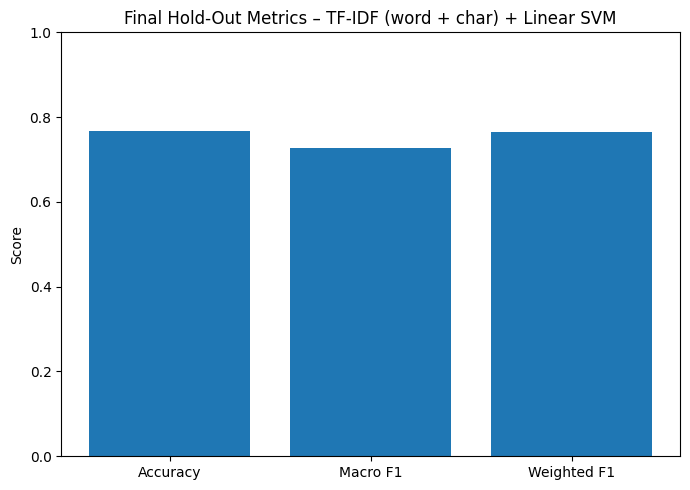

In [20]:
metrics_for_plot = pd.DataFrame({
    'metric': ['Accuracy', 'Macro F1', 'Weighted F1'],
    'score': [final_accuracy, final_macro_f1, final_weighted_f1]
})

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(metrics_for_plot['metric'], metrics_for_plot['score'])
ax.set_title(f'Final Hold-Out Metrics – {best_model_name}')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_final_holdout_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


,precision,recall,f1-score,support
Normal,0.8815,0.9440,0.9117,3269.0
Bipolar,0.8200,0.7536,0.7854,556.0
Anxiety,0.8025,0.7461,0.7733,768.0
Depression,0.7054,0.7167,0.7110,3081.0
Personality disorder,0.7471,0.6047,0.6684,215.0
Suicidal,0.6654,0.6523,0.6588,2131.0
Stress,0.6483,0.5242,0.5797,517.0


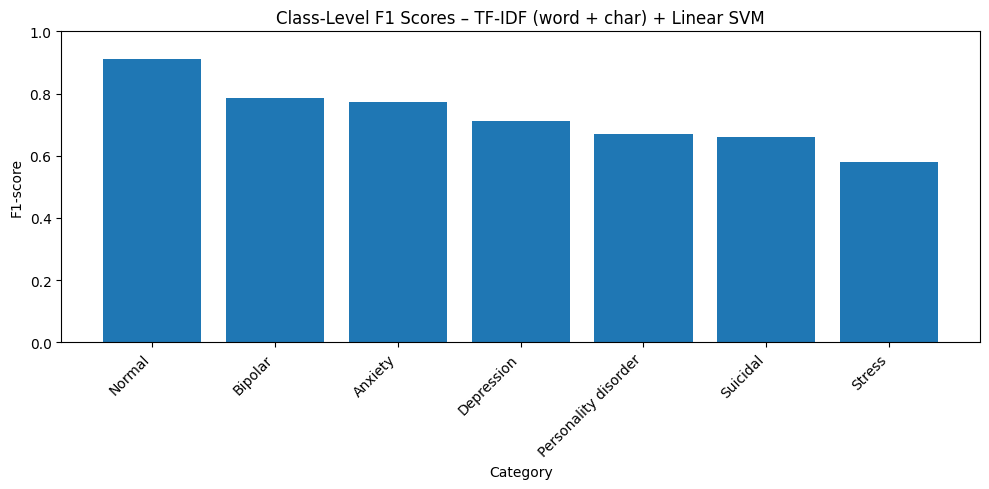

In [21]:
class_rows = [label for label in sorted(y.unique()) if label in classification_report_df.index]
class_f1_df = classification_report_df.loc[class_rows, ['precision', 'recall', 'f1-score', 'support']].copy()
class_f1_df = class_f1_df.sort_values('f1-score', ascending=False)
class_f1_df.to_csv(OUTPUT_DIR / 'class_level_metrics.csv')

display(class_f1_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(class_f1_df.index, class_f1_df['f1-score'])
ax.set_title(f'Class-Level F1 Scores – {best_model_name}')
ax.set_xlabel('Category')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_class_level_f1_scores.png', dpi=300, bbox_inches='tight')
plt.show()


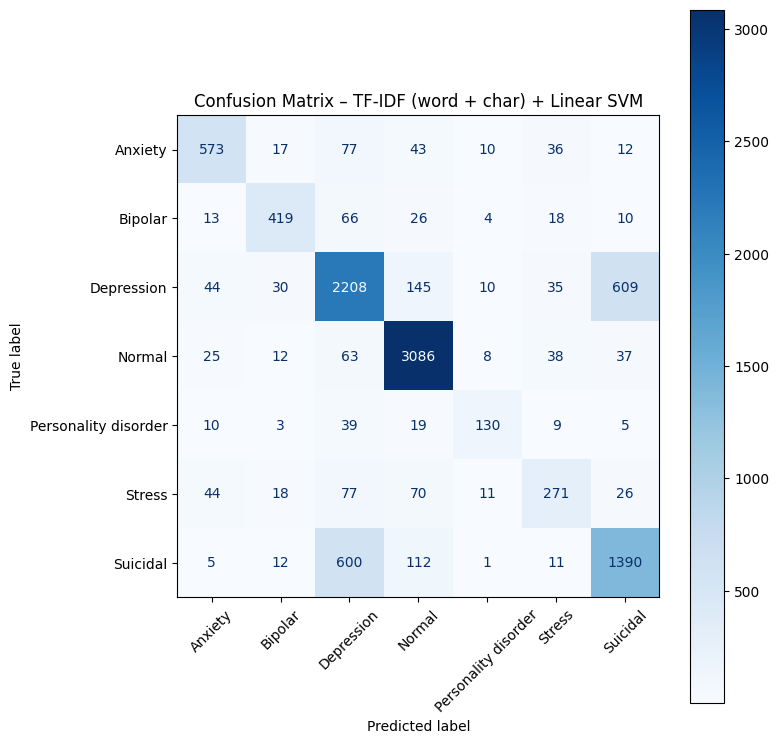

,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
Anxiety,573,17,77,43,10,36,12
Bipolar,13,419,66,26,4,18,10
Depression,44,30,2208,145,10,35,609
Normal,25,12,63,3086,8,38,37
Personality disorder,10,3,39,19,130,9,5
Stress,44,18,77,70,11,271,26
Suicidal,5,12,600,112,1,11,1390


In [22]:
class_order = [
    'Anxiety',
    'Bipolar',
    'Depression',
    'Normal',
    'Personality disorder',
    'Stress',
    'Suicidal'
]

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=class_order,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix – {best_model_name}')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_confusion_matrix_selected_model.png', dpi=300, bbox_inches='tight')
plt.show()

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=class_order),
    index=class_order,
    columns=class_order
)
cm_df.to_csv(OUTPUT_DIR / 'confusion_matrix.csv')
display(cm_df)


## 15. Experiment summary

The following cell prints a compact summary of the final modelling dataset, selected model, and hold-out metrics.


In [23]:
print('Dataset rows after removing empty statements:', len(df))
print('Best model selected from CV:', best_model_name)
print('Final hold-out accuracy:', round(final_accuracy, 4))
print('Final hold-out Macro F1:', round(final_macro_f1, 4))
print('Final hold-out Weighted F1:', round(final_weighted_f1, 4))
print('Saved outputs folder:', OUTPUT_DIR)


Dataset rows after removing empty statements: 52681
Best model selected from CV: TF-IDF (word + char) + Linear SVM
Final hold-out accuracy: 0.7665
Final hold-out Macro F1: 0.7269
Final hold-out Weighted F1: 0.7638
Saved outputs folder: /content/drive/MyDrive/mental_health_thesis_outputs


## 16. Post hoc lexical feature inspection

For the selected TF-IDF word-and-character Linear SVM model, top weighted lexical features are exported as a methodological transparency output. These features are model-specific indicators and should not be interpreted as clinical evidence.


In [24]:
if best_model_name == 'TF-IDF (word + char) + Linear SVM':
    feature_union = best_model.named_steps['features']
    svm_clf = best_model.named_steps['clf']

    word_vectorizer = dict(feature_union.transformer_list)['word_tfidf']
    char_vectorizer = dict(feature_union.transformer_list)['char_tfidf']

    word_features = [f'word::{f}' for f in word_vectorizer.get_feature_names_out()]
    char_features = [f'char::{f}' for f in char_vectorizer.get_feature_names_out()]
    all_features = np.array(word_features + char_features)

    class_names = svm_clf.classes_
    top_n = 20
    all_top_features = []

    for class_idx, class_name in enumerate(class_names):
        coefs = svm_clf.coef_[class_idx]
        top_idx = np.argsort(coefs)[-top_n:][::-1]

        class_features = pd.DataFrame({
            'class': class_name,
            'feature': all_features[top_idx],
            'weight': coefs[top_idx]
        })
        all_top_features.append(class_features)

    top_features_df = pd.concat(all_top_features, ignore_index=True)
    top_features_df.to_csv(OUTPUT_DIR / 'top_svm_features.csv', index=False)

    print('Top lexical features exported:', OUTPUT_DIR / 'top_svm_features.csv')
    display(top_features_df.head(10))
else:
    print('The selected model is not the TF-IDF word-and-character Linear SVM configuration.')
    print('Post hoc lexical feature inspection was skipped.')


Top lexical features exported: /content/drive/MyDrive/mental_health_thesis_outputs/top_svm_features.csv


,class,feature,weight
0,Anxiety,word::restless,3.207594
1,Anxiety,word::nervous,2.863059
2,Anxiety,word::stressing,2.099933
3,Anxiety,char::estl,1.971225
4,Anxiety,word::rabies,1.904760
5,Anxiety,word::googling,1.729195
6,Anxiety,word::hiv,1.695569
7,Anxiety,word::amp x200b,1.645811
8,Anxiety,word::go doctor,1.617804
9,Anxiety,word::anxiety,1.589856


## 17. Artefact screening

This step checks whether clearly URL- or platform-related word-level tokens appear among the fitted lexical features. The purpose is to document possible dataset-specific artefacts.


In [25]:
if best_model_name == 'TF-IDF (word + char) + Linear SVM':
    suspicious_word_tokens = {'rt', 'http', 'https', 'url', 'www', 'com'}
    suspicious_rows = []

    for class_idx, class_name in enumerate(class_names):
        coefs = svm_clf.coef_[class_idx]

        for idx, feat in enumerate(all_features):
            feat_text = feat.lower()

            if feat_text.startswith('word::'):
                token = feat_text.replace('word::', '').strip()
                token_parts = token.split()

                if token in suspicious_word_tokens or any(part in suspicious_word_tokens for part in token_parts):
                    suspicious_rows.append({
                        'class': class_name,
                        'feature': feat,
                        'weight': coefs[idx]
                    })

    df_suspicious_strict = pd.DataFrame(suspicious_rows)

    if not df_suspicious_strict.empty:
        df_suspicious_strict = df_suspicious_strict.sort_values(
            by=['class', 'weight'],
            ascending=[True, False]
        )
        df_suspicious_strict.to_csv(OUTPUT_DIR / 'suspicious_word_level_artefacts.csv', index=False)
        print('Clearly suspicious word-level features found:')
        display(df_suspicious_strict)
    else:
        print('No clearly suspicious word-level features were found.')
else:
    print('The winning model is not the TF-IDF (word + char) + Linear SVM configuration.')


Clearly suspicious word-level features found:


,class,feature,weight
0,Anxiety,word::com,0.480722
3,Anxiety,word::http www,0.338800
7,Anxiety,word::www,0.246837
8,Anxiety,word::www reddit,0.158921
4,Anxiety,word::reddit com,0.158337
...,...,...,...
61,Suicidal,word::www,-0.612370
57,Suicidal,word::http www,-0.617893
60,Suicidal,word::url,-0.821950
54,Suicidal,word::com,-1.004510


## 18. Output archive

The exported CSV and PNG files are compressed into a ZIP archive for convenient storage and sharing.


In [26]:
import shutil
from pathlib import Path

output_folder = Path('/content/drive/MyDrive/mental_health_thesis_outputs')
zip_base = Path('/content/drive/MyDrive/mental_health_thesis_outputs')
zip_file = Path(str(zip_base) + '.zip')

if zip_file.exists():
    zip_file.unlink()

shutil.make_archive(
    base_name=str(zip_base),
    format='zip',
    root_dir=str(output_folder)
)

print('ZIP created at:', zip_file)
print('Number of files included:', len(list(output_folder.iterdir())))


ZIP created at: /content/drive/MyDrive/mental_health_thesis_outputs.zip
Number of files included: 17
